# Color Palette (`color_idea`) Multi-Label Baseline




In [15]:
# ============================================================
# 1. INSTALL + IMPORTS
# ============================================================

!pip -q install scikit-learn pandas numpy matplotlib seaborn torch

import os
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, hamming_loss, precision_recall_fscore_support,
    classification_report,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [16]:
# ============================================================
# 2. CONFIG
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/SoftCom Project/Dataset"
SPLITS_FOLDER = "/content/drive/MyDrive/SoftCom Project/Dataset"

# The .npz produced by dinov2_baseline.ipynb (Part 5 of that notebook)
EMBEDDINGS_PATH = "/content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results/DINOv2/dinov2_embeddings_dinov2_vits14.npz"

OUTPUT_FOLDER = os.path.join(DATASET_ROOT, "Baseline_Results_ColorPalette")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Only colors appearing at least this often get their own label -- rarer colors are excluded
# from the modeled set until more data is collected (see markdown note above).
MIN_COLOR_FREQUENCY = 15

LINEAR_HEAD_EPOCHS = 40
LINEAR_HEAD_LR = 1e-3


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load splits + cached embeddings

In [17]:
# ============================================================
# 3. LOAD SPLITS
# ============================================================

def load_split(name):
    path = os.path.join(SPLITS_FOLDER, name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {path}\nCheck SPLITS_FOLDER in the CONFIG cell.")
    return pd.read_csv(path, encoding="utf-8-sig")

train_df = load_split("train.csv")
val_df   = load_split("validation.csv")
test_df  = load_split("test.csv")

train_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("Train pool:", len(train_pool_df), "| Test (held out):", len(test_df))


Train pool: 264 | Test (held out): 24


In [18]:
# ============================================================
# 4. LOAD CACHED DINOv2 EMBEDDINGS
# ============================================================

if not os.path.exists(EMBEDDINGS_PATH):
    raise FileNotFoundError(
        f"Could not find {EMBEDDINGS_PATH}\n"
        "Run dinov2_baseline.ipynb first (Part 5, embedding extraction + caching)."
    )

cache = np.load(EMBEDDINGS_PATH, allow_pickle=True)
embedding_lookup = dict(zip(cache["image_ids"], cache["embeddings"]))
EMBED_DIM = next(iter(embedding_lookup.values())).shape[0]
print(f"Loaded {len(embedding_lookup)} cached embeddings, dim={EMBED_DIM}")

def attach_available_embeddings(df):
    df = df.copy()
    available = df["image_id"].isin(embedding_lookup.keys())
    if (~available).sum() > 0:
        print(f"⚠️  {(~available).sum()} images missing from embedding cache, dropped: "
              f"{df.loc[~available, 'image_id'].tolist()}")
    return df[available].reset_index(drop=True)

train_pool_df = attach_available_embeddings(train_pool_df)
test_df = attach_available_embeddings(test_df)
print("After embedding check -> Train pool:", len(train_pool_df), "| Test:", len(test_df))


Loaded 288 cached embeddings, dim=384
After embedding check -> Train pool: 264 | Test: 24


## Parse `color_idea` and pick the modeled label set

In [19]:
# ============================================================
# 5. PARSE COLORS + SELECT LABEL SET
# ============================================================

def parse_colors(value):
    return [c.strip().lower() for c in str(value).split(",") if c.strip()]

train_pool_df["color_list"] = train_pool_df["color_idea"].apply(parse_colors)
test_df["color_list"] = test_df["color_idea"].apply(parse_colors)

color_counts = Counter(c for colors in train_pool_df["color_list"] for c in colors)
print("Color frequency (train pool):")
for color, count in color_counts.most_common():
    marker = "✓ modeled" if count >= MIN_COLOR_FREQUENCY else "  excluded (too rare)"
    print(f"  {color:15s} {count:3d}  {marker}")

MODELED_COLORS = sorted([c for c, count in color_counts.items() if count >= MIN_COLOR_FREQUENCY])
print(f"\nModeling {len(MODELED_COLORS)} colors: {MODELED_COLORS}")

def filter_to_modeled(colors):
    return [c for c in colors if c in MODELED_COLORS]

train_pool_df["color_list_filtered"] = train_pool_df["color_list"].apply(filter_to_modeled)
test_df["color_list_filtered"] = test_df["color_list"].apply(filter_to_modeled)


Color frequency (train pool):
  yellow          205  ✓ modeled
  green           154  ✓ modeled
  white           151  ✓ modeled
  red             148  ✓ modeled
  black           138  ✓ modeled
  blue            128  ✓ modeled
  pink             96  ✓ modeled
  orange           90  ✓ modeled
  brown            52  ✓ modeled
  gold             43  ✓ modeled
  purple           34  ✓ modeled
  silver           11    excluded (too rare)
  grey             10    excluded (too rare)
  beige             8    excluded (too rare)
  maroon            6    excluded (too rare)
  teal              5    excluded (too rare)
  dark blue         5    excluded (too rare)
  lime              4    excluded (too rare)
  light blue        3    excluded (too rare)
  turquoise         3    excluded (too rare)
  magenta           2    excluded (too rare)
  pastel blue       2    excluded (too rare)
  pastel yellow     2    excluded (too rare)
  cream             2    excluded (too rare)
  pastel pink       1 

In [20]:
# ============================================================
# 6. MULTI-LABEL BINARIZATION
# ============================================================

mlb = MultiLabelBinarizer(classes=MODELED_COLORS)
Y_train = mlb.fit_transform(train_pool_df["color_list_filtered"])
Y_test  = mlb.transform(test_df["color_list_filtered"])

X_train = np.stack([embedding_lookup[iid] for iid in train_pool_df["image_id"]])
X_test  = np.stack([embedding_lookup[iid] for iid in test_df["image_id"]])

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test: ", X_test.shape, "Y_test: ", Y_test.shape)


X_train: (264, 384) Y_train: (264, 11)
X_test:  (24, 384) Y_test:  (24, 11)


## Naive baseline




In [21]:
# ============================================================
# 7. NAIVE BASELINE
# ============================================================

results = []

train_prevalence = Y_train.mean(axis=0)
naive_prediction_row = (train_prevalence > 0.5).astype(int)
Y_pred_naive = np.tile(naive_prediction_row, (len(Y_test), 1))

subset_acc = accuracy_score(Y_test, Y_pred_naive)
micro_f1 = f1_score(Y_test, Y_pred_naive, average="micro", zero_division=0)
macro_f1 = f1_score(Y_test, Y_pred_naive, average="macro", zero_division=0)
h_loss = hamming_loss(Y_test, Y_pred_naive)

results.append({"method": "naive_majority", "subset_accuracy": subset_acc,
                 "micro_f1": micro_f1, "macro_f1": macro_f1, "hamming_loss": h_loss})
print(f"[naive] subset_acc={subset_acc:.3f} micro_f1={micro_f1:.3f} macro_f1={macro_f1:.3f} hamming_loss={h_loss:.3f}")


[naive] subset_acc=0.000 micro_f1=0.626 macro_f1=0.349 hamming_loss=0.345


## Baseline 1 — OneVsRest Logistic Regression on frozen DINOv2 features

In [22]:
# ============================================================
# 8. ONE-VS-REST LOGISTIC REGRESSION
# ============================================================

ovr_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
)
ovr_clf.fit(X_train, Y_train)
Y_pred_ovr = ovr_clf.predict(X_test)

subset_acc = accuracy_score(Y_test, Y_pred_ovr)
micro_f1 = f1_score(Y_test, Y_pred_ovr, average="micro", zero_division=0)
macro_f1 = f1_score(Y_test, Y_pred_ovr, average="macro", zero_division=0)
h_loss = hamming_loss(Y_test, Y_pred_ovr)

results.append({"method": "frozen_dinov2_ovr_logreg", "subset_accuracy": subset_acc,
                 "micro_f1": micro_f1, "macro_f1": macro_f1, "hamming_loss": h_loss})
print(f"[OVR logreg] subset_acc={subset_acc:.3f} micro_f1={micro_f1:.3f} macro_f1={macro_f1:.3f} hamming_loss={h_loss:.3f}")

print(f"\nPer-color report (OVR Logistic Regression):")
print(classification_report(Y_test, Y_pred_ovr, target_names=MODELED_COLORS, zero_division=0))


[OVR logreg] subset_acc=0.042 micro_f1=0.594 macro_f1=0.508 hamming_loss=0.352

Per-color report (OVR Logistic Regression):
              precision    recall  f1-score   support

       black       0.54      0.64      0.58        11
        blue       0.71      0.33      0.45        15
       brown       0.33      0.67      0.44         3
        gold       0.00      0.00      0.00         0
       green       0.83      0.53      0.65        19
      orange       0.29      0.25      0.27         8
        pink       0.75      0.64      0.69        14
      purple       0.67      0.29      0.40         7
         red       0.50      0.62      0.55        13
       white       0.77      0.67      0.71        15
      yellow       1.00      0.72      0.84        18

   micro avg       0.64      0.55      0.59       123
   macro avg       0.58      0.49      0.51       123
weighted avg       0.71      0.55      0.61       123
 samples avg       0.63      0.55      0.58       123



## Baseline 2 — trainable multi-label linear head (PyTorch)


In [23]:
# ============================================================
# 9. TRAINABLE MULTI-LABEL LINEAR HEAD
# ============================================================

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(DEVICE)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(DEVICE)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32).to(DEVICE)

# pos_weight per label = (negatives / positives), so under-represented colors get upweighted
num_pos = Y_train.sum(axis=0)
num_neg = len(Y_train) - num_pos
pos_weight = torch.tensor(num_neg / np.maximum(num_pos, 1), dtype=torch.float32).to(DEVICE)

head = nn.Linear(EMBED_DIM, len(MODELED_COLORS)).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(head.parameters(), lr=LINEAR_HEAD_LR)

for epoch in range(1, LINEAR_HEAD_EPOCHS + 1):
    head.train()
    optimizer.zero_grad()
    loss = criterion(head(X_train_t), Y_train_t)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0 or epoch == LINEAR_HEAD_EPOCHS:
        print(f"  epoch {epoch:02d}/{LINEAR_HEAD_EPOCHS} loss={loss.item():.3f}")

head.eval()
with torch.no_grad():
    probs = torch.sigmoid(head(X_test_t)).cpu().numpy()
Y_pred_head = (probs >= 0.5).astype(int)

subset_acc = accuracy_score(Y_test, Y_pred_head)
micro_f1 = f1_score(Y_test, Y_pred_head, average="micro", zero_division=0)
macro_f1 = f1_score(Y_test, Y_pred_head, average="macro", zero_division=0)
h_loss = hamming_loss(Y_test, Y_pred_head)

results.append({"method": "frozen_dinov2_linear_head", "subset_accuracy": subset_acc,
                 "micro_f1": micro_f1, "macro_f1": macro_f1, "hamming_loss": h_loss})
print(f"\n[linear head] subset_acc={subset_acc:.3f} micro_f1={micro_f1:.3f} macro_f1={macro_f1:.3f} hamming_loss={h_loss:.3f}")

print(f"\nPer-color report (trainable linear head):")
print(classification_report(Y_test, Y_pred_head, target_names=MODELED_COLORS, zero_division=0))


  epoch 10/40 loss=0.725
  epoch 20/40 loss=0.577
  epoch 30/40 loss=0.486
  epoch 40/40 loss=0.423

[linear head] subset_acc=0.000 micro_f1=0.621 macro_f1=0.527 hamming_loss=0.333

Per-color report (trainable linear head):
              precision    recall  f1-score   support

       black       0.62      0.73      0.67        11
        blue       0.71      0.33      0.45        15
       brown       0.12      0.33      0.18         3
        gold       0.00      0.00      0.00         0
       green       0.86      0.63      0.73        19
      orange       0.50      0.50      0.50         8
        pink       0.86      0.86      0.86        14
      purple       0.50      0.43      0.46         7
         red       0.50      0.31      0.38        13
       white       0.92      0.73      0.81        15
      yellow       0.86      0.67      0.75        18

   micro avg       0.66      0.59      0.62       123
   macro avg       0.59      0.50      0.53       123
weighted avg      

## Results comparison

,method,subset_accuracy,micro_f1,macro_f1,hamming_loss
0,naive_majority,0.000000,0.625514,0.349215,0.344697
1,frozen_dinov2_ovr_logreg,0.041667,0.593886,0.508289,0.352273
2,frozen_dinov2_linear_head,0.000000,0.620690,0.526796,0.333333


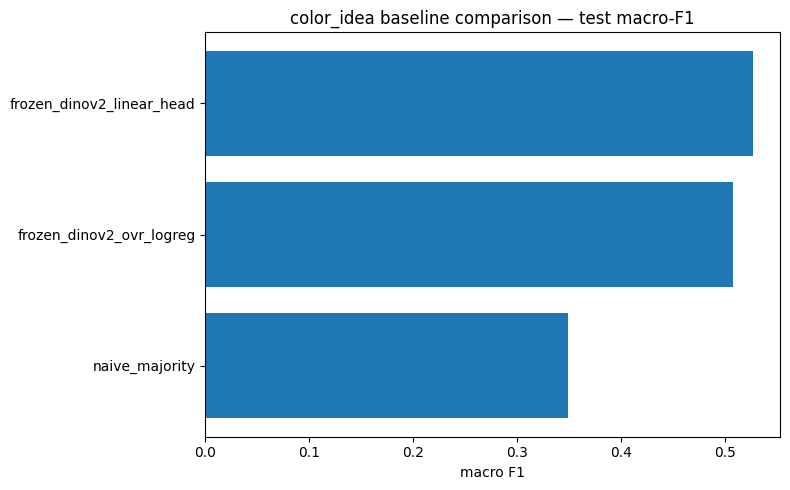

In [24]:
# ============================================================
# 10. RESULTS TABLE + CHART
# ============================================================

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_FOLDER, "color_baseline_results.csv"), index=False)
display(results_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(results_df["method"], results_df["macro_f1"])
ax.set_xlabel("macro F1")
ax.set_title("color_idea baseline comparison — test macro-F1")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "color_baseline_comparison.png"), dpi=150)
plt.show()


## Per-color performance breakdown



,color,precision,recall,f1,support
6,pink,0.857143,0.857143,0.857143,14
9,white,0.916667,0.733333,0.814815,15
10,yellow,0.857143,0.666667,0.750000,18
4,green,0.857143,0.631579,0.727273,19
0,black,0.615385,0.727273,0.666667,11
5,orange,0.500000,0.500000,0.500000,8
7,purple,0.500000,0.428571,0.461538,7
1,blue,0.714286,0.333333,0.454545,15
8,red,0.500000,0.307692,0.380952,13
2,brown,0.125000,0.333333,0.181818,3


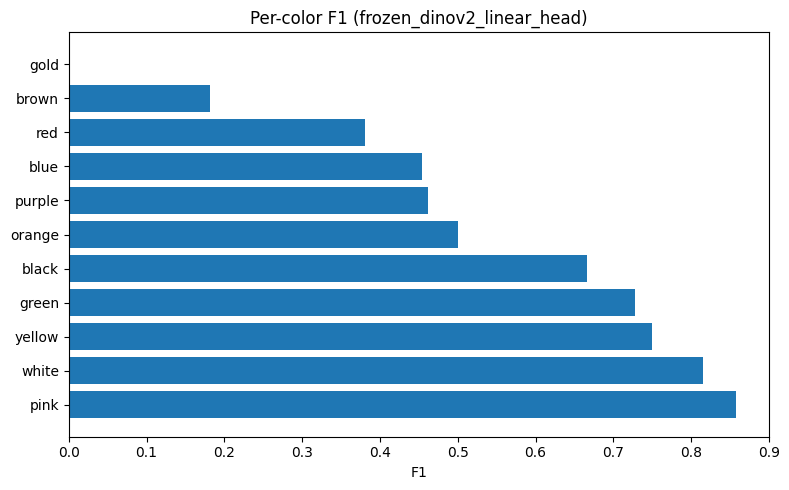

In [25]:
# ============================================================
# 11. PER-COLOR F1 BREAKDOWN (BEST METHOD)
# ============================================================

best_method_name = results_df.sort_values("macro_f1", ascending=False).iloc[0]["method"]
Y_pred_best = Y_pred_head if best_method_name == "frozen_dinov2_linear_head" else Y_pred_ovr

precision, recall, f1, support = precision_recall_fscore_support(
    Y_test, Y_pred_best, zero_division=0
)
per_color_df = pd.DataFrame({
    "color": MODELED_COLORS, "precision": precision, "recall": recall,
    "f1": f1, "support": support,
}).sort_values("f1", ascending=False)

display(per_color_df)

plt.figure(figsize=(8, 5))
plt.barh(per_color_df["color"], per_color_df["f1"])
plt.xlabel("F1")
plt.title(f"Per-color F1 ({best_method_name})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "color_per_label_f1.png"), dpi=150)
plt.show()


## GroupKFold cross-validation

In [27]:
# ============================================================
# GROUP K-FOLD CROSS-VALIDATION (color_idea, multi-label)
# ============================================================

from sklearn.model_selection import GroupKFold

N_FOLDS = 5

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
full_df = attach_available_embeddings(full_df)
full_df["color_list"] = full_df["color_idea"].apply(parse_colors)
full_df["color_list_filtered"] = full_df["color_list"].apply(filter_to_modeled)

X_full = np.stack([embedding_lookup[iid] for iid in full_df["image_id"]])
Y_full = mlb.transform(full_df["color_list_filtered"])
groups = full_df["group_id"].values

n_splits = min(N_FOLDS, pd.Series(groups).nunique())
gkf = GroupKFold(n_splits=n_splits)

fold_metrics = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full, Y_full, groups), start=1):
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)
    )
    clf.fit(X_full[train_idx], Y_full[train_idx])
    Y_pred = clf.predict(X_full[test_idx])

    fold_macro_f1 = f1_score(Y_full[test_idx], Y_pred, average="macro", zero_division=0)
    fold_micro_f1 = f1_score(Y_full[test_idx], Y_pred, average="micro", zero_division=0)
    fold_subset_acc = accuracy_score(Y_full[test_idx], Y_pred)
    fold_hamming = hamming_loss(Y_full[test_idx], Y_pred)

    fold_metrics.append({
        "fold": fold, "macro_f1": fold_macro_f1, "micro_f1": fold_micro_f1,
        "subset_accuracy": fold_subset_acc, "hamming_loss": fold_hamming,
    })
    print(f"[fold {fold}/{n_splits}] macro_f1={fold_macro_f1:.3f} micro_f1={fold_micro_f1:.3f} "
          f"subset_acc={fold_subset_acc:.3f} hamming_loss={fold_hamming:.3f}")

fold_df = pd.DataFrame(fold_metrics)
summary = {
    "method": "frozen_dinov2_ovr_logreg_groupkfold",
    "mean_macro_f1": fold_df["macro_f1"].mean(), "std_macro_f1": fold_df["macro_f1"].std(),
    "mean_micro_f1": fold_df["micro_f1"].mean(), "std_micro_f1": fold_df["micro_f1"].std(),
    "mean_subset_accuracy": fold_df["subset_accuracy"].mean(), "std_subset_accuracy": fold_df["subset_accuracy"].std(),
    "mean_hamming_loss": fold_df["hamming_loss"].mean(), "std_hamming_loss": fold_df["hamming_loss"].std(),
}
print(f"\n{n_splits}-fold mean macro_f1 = {summary['mean_macro_f1']:.3f} ± {summary['std_macro_f1']:.3f}")

pd.DataFrame([summary]).to_csv(os.path.join(OUTPUT_FOLDER, "color_groupkfold_results.csv"), index=False)
fold_df.to_csv(os.path.join(OUTPUT_FOLDER, "color_groupkfold_per_fold.csv"), index=False)
display(pd.DataFrame([summary]))


[fold 1/5] macro_f1=0.535 micro_f1=0.628 subset_acc=0.000 hamming_loss=0.318
[fold 2/5] macro_f1=0.486 micro_f1=0.600 subset_acc=0.020 hamming_loss=0.349
[fold 3/5] macro_f1=0.479 micro_f1=0.606 subset_acc=0.020 hamming_loss=0.340
[fold 4/5] macro_f1=0.517 micro_f1=0.595 subset_acc=0.000 hamming_loss=0.336
[fold 5/5] macro_f1=0.522 micro_f1=0.595 subset_acc=0.041 hamming_loss=0.349

5-fold mean macro_f1 = 0.508 ± 0.024


,method,mean_macro_f1,std_macro_f1,mean_micro_f1,std_micro_f1,mean_subset_accuracy,std_subset_accuracy,mean_hamming_loss,std_hamming_loss
0,frozen_dinov2_ovr_logreg_groupkfold,0.507862,0.024455,0.604864,0.013803,0.016163,0.017027,0.338375,0.012653


In [28]:
# ============================================================
# 12. SAVE THE BEST TRAINED MODEL (for reuse in image_text_fusion_retrieval.ipynb)
# ============================================================

import json as json_lib
import joblib

MODEL_INFO_PATH = os.path.join(OUTPUT_FOLDER, "color_model_info.json")

if best_method_name == "frozen_dinov2_linear_head":
    torch.save(head.state_dict(), os.path.join(OUTPUT_FOLDER, "color_linear_head.pt"))
    model_info = {"method": "linear_head", "embed_dim": EMBED_DIM, "modeled_colors": MODELED_COLORS}
    print(f"Saved PyTorch linear head -> {os.path.join(OUTPUT_FOLDER, 'color_linear_head.pt')}")
else:
    joblib.dump(ovr_clf, os.path.join(OUTPUT_FOLDER, "color_ovr_logreg.joblib"))
    model_info = {"method": "ovr_logreg", "embed_dim": EMBED_DIM, "modeled_colors": MODELED_COLORS}
    print(f"Saved OVR Logistic Regression -> {os.path.join(OUTPUT_FOLDER, 'color_ovr_logreg.joblib')}")

with open(MODEL_INFO_PATH, "w") as f:
    json_lib.dump(model_info, f, indent=2)
print(f"Saved model info (method + color list) -> {MODEL_INFO_PATH}")
print(f"\nBest method: {best_method_name} (macro_f1={results_df.set_index('method').loc[best_method_name, 'macro_f1']:.3f})")


Saved PyTorch linear head -> /content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results_ColorPalette/color_linear_head.pt
Saved model info (method + color list) -> /content/drive/MyDrive/SoftCom Project/Dataset/Baseline_Results_ColorPalette/color_model_info.json

Best method: frozen_dinov2_linear_head (macro_f1=0.527)
